## Option Basics, BSM model

---

a.) Smart up our plotter to be able to customize the hard-coded layout setup inside the function. Add more custom features that you would like to use.

b.) Upgrade the BSM call option pricer to be able to return the greeks as well, not just the price.

c.) Implement the BSM pricer for European put option.

d.) With the call and put pricer, check if Put-Call parity holds in practice

## Imports

In [1]:
from __future__ import annotations
from typing import Dict, List, Union

from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.axes import Axes
from matplotlib.figure import Figure

## a.) Updating the plotter

---

In [2]:
DEFAULTS = {
    "figsize": (10, 5),
    "style": "seaborn-v0_8-whitegrid",
    "title_fontsize": 18,
    "label_fontsize": 14,
    "tick_fontsize": 11,
    "legend_loc": "best",
    "title_size": 18,
    "label_size": 14,
    "grid_alpha": 0.3
}

PALETTE: List[str] = [
    "#E63946", # vivid red
    "#457B9D", # steel blue
    "#2A9D8F", # teal
    "#E9C46A", # saffron
    "#8338EC", # violet
    "#FB5607", # orange
    "#3A86FF", # cobalt
    "#06D6A0", # mint
]

def my_plotter(
        x: List[float],
        y: Union[List[float],
        List[List[float]]],
        layout: Dict = {},
        colors = None,
        names: List[str] = None,
) -> None:
    y = [y] if all(isinstance(item, float) for item in y) else y

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=DEFAULTS["figsize"])

    # Plot each series
    x_arr = np.array(x, dtype=float)

    plot_colors = colors if colors else PALETTE

    for i, data_series in enumerate(y):
        color = plot_colors[i % len(plot_colors)]
        label = names[i] if names and i < len(names) else None

        ax.plot(x, data_series, label=label, color=color, linewidth=2.5, zorder=3)

    if "title" in layout:
        ax.set_title(layout['title'], fontsize=DEFAULTS["title_size"], pad=20)
    if 'x_label' in layout:
        ax.set_xlabel(layout['x_label'], fontsize=DEFAULTS["label_size"])
    if "y_label" in layout:
        ax.set_ylabel(layout['y_label'], fontsize=DEFAULTS["label_size"])

    ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)

    if names:
        ax.legend(loc="best")

    plt.tight_layout()
    plt.show()

    plt.show()


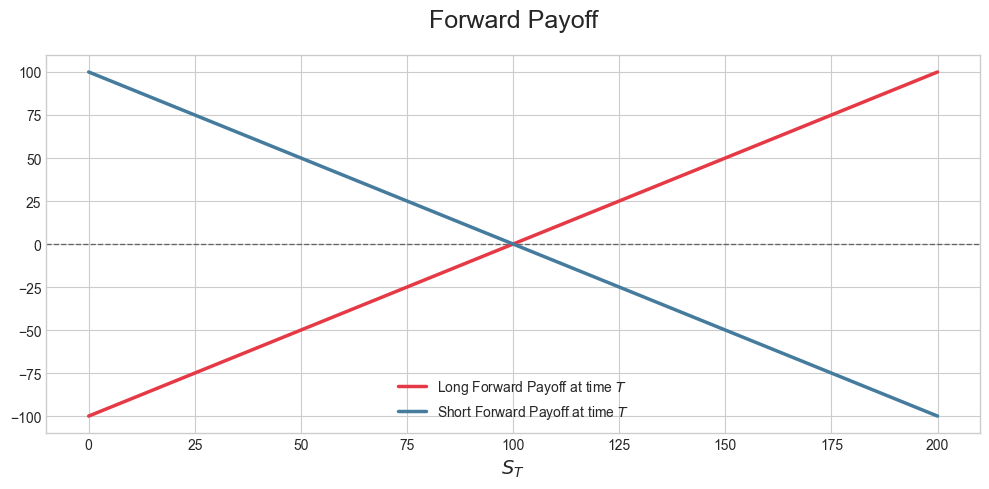

In [3]:
strike = 100
step_size = 0.001

x_stock_price = np.arange(0, 2 * strike, step_size)
y_forward_payoff = np.array([x - strike for x in x_stock_price])

y_forward_payoff__short = y_forward_payoff * (-1)
y_forward_payoff__short

layout = {'title': 'Forward', 'x_label': '$S_{T}$'}
my_plotter(
    x_stock_price,
    [y_forward_payoff, y_forward_payoff__short],
    layout={
        "title": 'Forward Payoff',
        "x_label": '$S_{T}$'},
    names=[
        'Long Forward Payoff at time $T$',
        'Short Forward Payoff at time $T$'
    ],

)

In [4]:
# The pricing function of European call option
def black_scholes_eur_call(
        r: float,
        T: float,
        S0: float,
        sigma: float,
        K: Union[float,
        List[float],
        np.ndarray],
        S_at_t=None
) -> np.ndarray:
    """
    Black-Scholes pricer of European call option on non-dividend-paying stock

    param r: risk-free interest rate (which is constant)
    param T: time to maturity (in years)
    param S0: initial spot price of the underlying stock
    param sigma: volatility of the underlying stock
    param K: strike price (or prices)
    """
    # check conditions
    assert sigma > 0

    K = np.array([K]) if isinstance(K, float) else np.array(K)

    d1_vec = (np.log(S0 / K ) + (r + 0.5 * sigma**2) * T) / (sigma * T**0.5)
    d2_vec = d1_vec - sigma * T**0.5

    N_d1_vec = norm.cdf(d1_vec)
    N_d2_vec = norm.cdf(d2_vec)

    # Vega
    vega = S0 * norm.pdf(d1_vec) * T**0.5

    # Theta
    theta = -S0 * norm.cdf(d1_vec) * sigma / (2 * (T)**0.5) - r * K * np.exp(-r * T) * norm.cdf(d2_vec)

    # Rho
    rho = K * T * np.exp(-r * T) * norm.cdf(d2_vec)

    # Gamma
    gamma = norm.pdf(d1_vec) * (1 / (S0 * sigma * (T)** 0.5))

    return (
        N_d1_vec * S0 - K * np.exp((-1.0) * r * T) * N_d2_vec,
        d1_vec,
        vega,
        theta,
        rho,
        gamma
    )


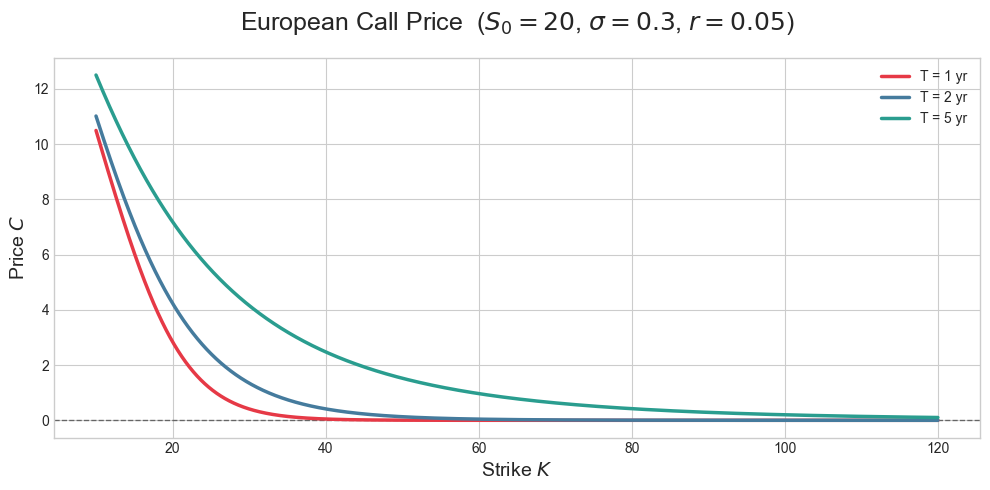

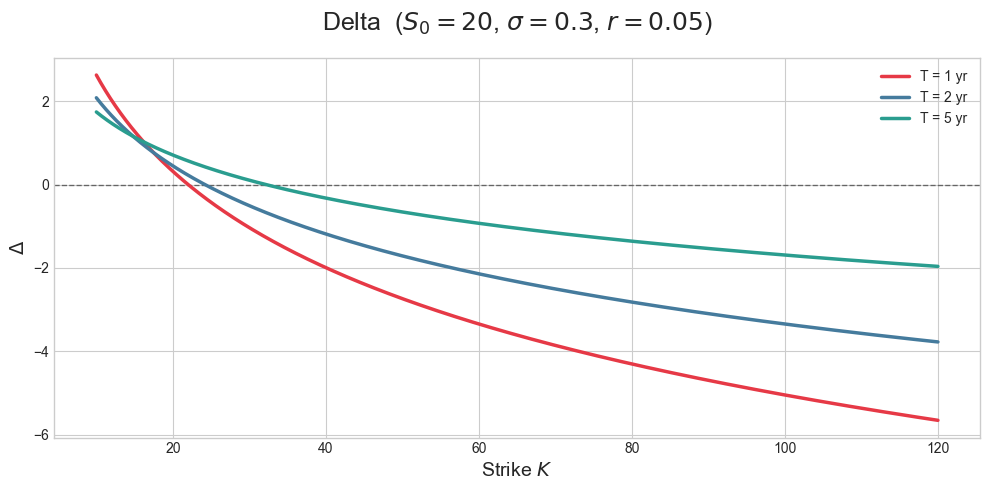

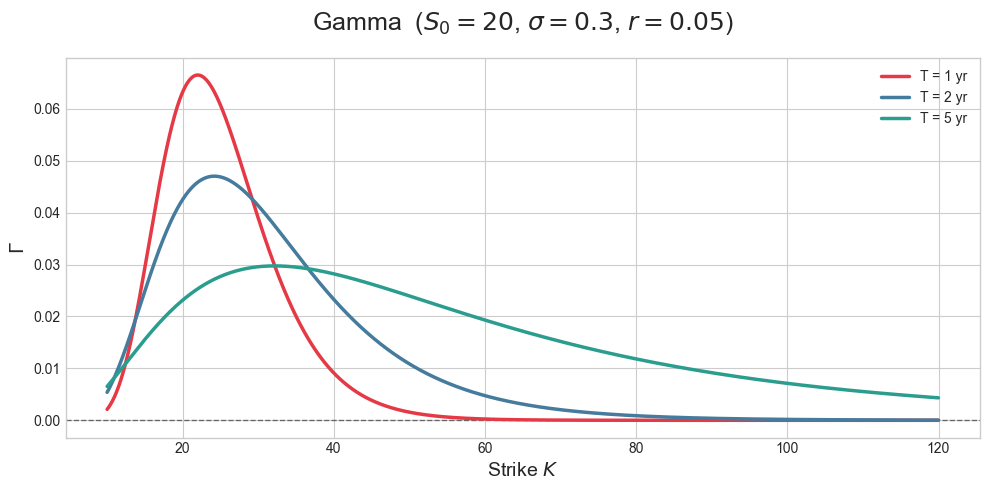

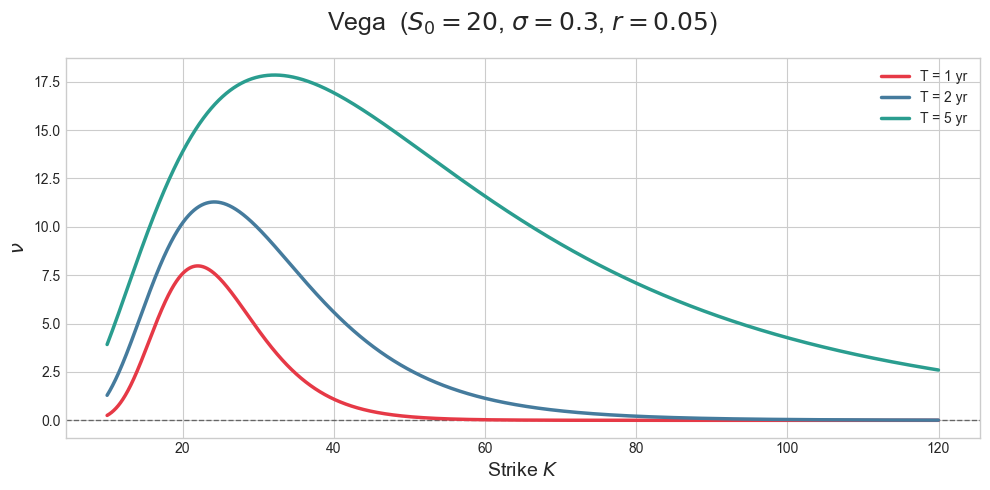

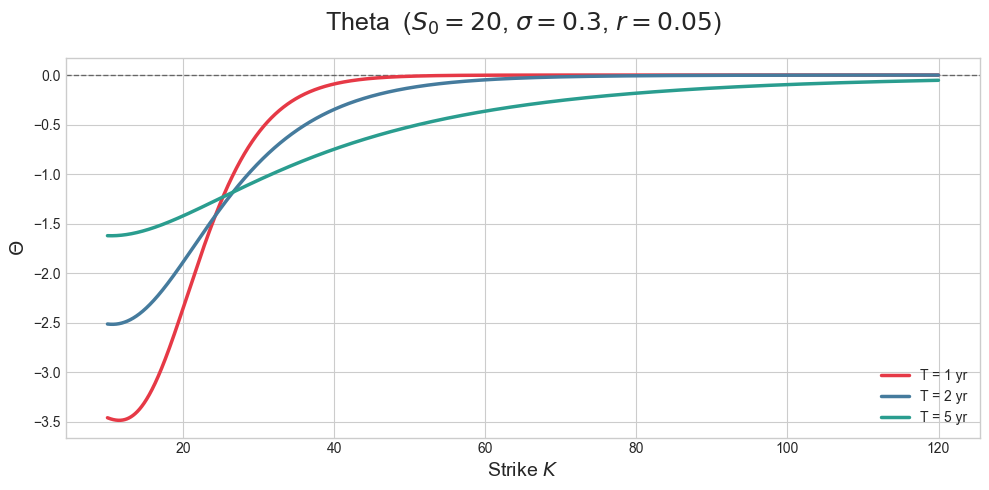

In [19]:
K_vec = np.arange(10, 120, 0.01)
T_vec = [1.0, 2.0, 5.0]
S0 = 20
sigma = 0.3

call_prices, deltas, vegas, thetas, rhos, gammas = zip(
    *[
        black_scholes_eur_call(
            K=K_vec, r=0.05, T=T, S0=S0, sigma=sigma) for T in T_vec
    ]
)

params = [
    ("European Call Price", list(call_prices), "Price $C$"),
    ("Delta", list(deltas), r"$\Delta$"),
    ("Gamma", list(gammas), r"$\Gamma$"),
    ("Vega", list(vegas), r"$\nu$"),
    ("Theta", list(thetas), r"$\Theta$"),
]

for greek, y_data, y_label in params:
    my_plotter(
        x=K_vec,
        y=y_data,
        names=["T = 1 yr", "T = 2 yr", "T = 5 yr"],
        layout={
            "title": rf"{greek}  ($S_0={S0}$, $\sigma={sigma}$, $r=0.05$)",
            "x_label": "Strike $K$",
            "y_label": y_label,
        },
    )

In [8]:
# The pricing function of European put option
def black_scholes_eur_put(
        r: float,
        T: float,
        S0: float,
        sigma: float,
        K: Union[float,
        List[float],
        np.ndarray],
        S_at_t=None
) -> np.ndarray:
    """
    Black-Scholes pricer of European put option on non-dividend-paying stock

    param r: risk-free interest rate (which is constant)
    param T: time to maturity (in years)
    param S0: initial spot price of the underlying stock
    param sigma: volatility of the underlying stock
    param K: strike price (or prices)
    """
    # check conditions
    assert sigma > 0

    K = np.array([K]) if isinstance(K, float) else np.array(K)

    d1_vec = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * T**0.5)
    d2_vec = d1_vec - sigma * T**0.5

    neg_N_d1_vec = norm.cdf(-d1_vec)
    neg_N_d2_vec = norm.cdf(-d2_vec)

    # : K·e^(-rT)·N(-d2) - S0·N(-d1)
    price = - neg_N_d1_vec * S0 + K_vec * np.exp(-r * T) * neg_N_d2_vec

    # Vega
    vega = S0 * norm.pdf(d1_vec) * T**0.5

    # Theta for put: gains the +r·K·e^(-rT)·N(-d2) term vs call
    theta = -S0 * norm.cdf(d1_vec) * sigma / (2 * (T)**0.5) + r * K * np.exp(-r * T) * neg_N_d2_vec

    # Rho for put: negative — put loses value as r increases
    rho = -K * T * np.exp(-r * T) * neg_N_d2_vec

    # Gamma
    gamma = norm.pdf(d1_vec) / (S0 * sigma * (T)** 0.5)

    return (
        price,
        d1_vec,
        vega,
        theta,
        rho,
        gamma
    )


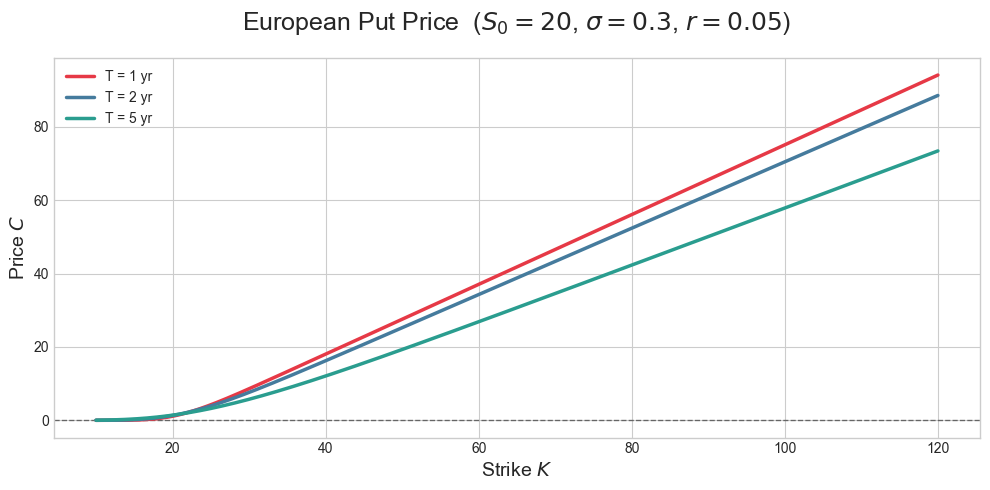

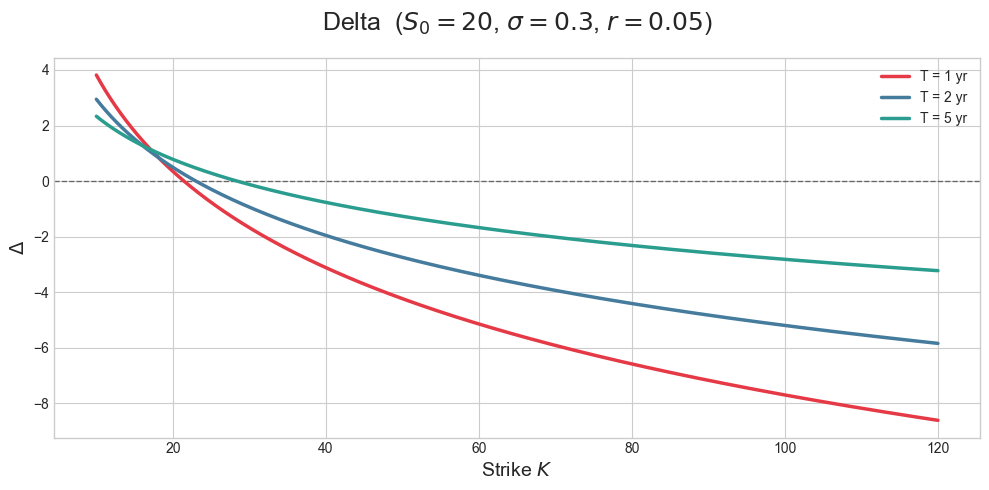

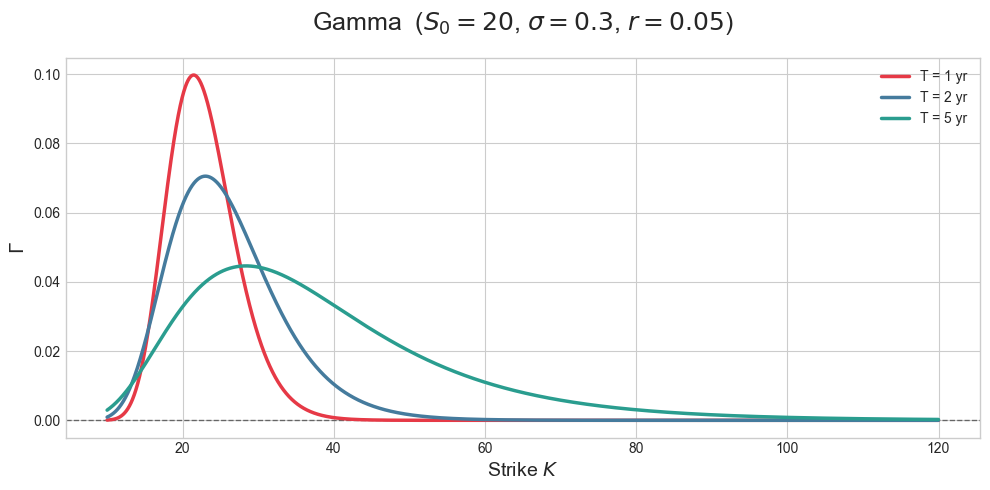

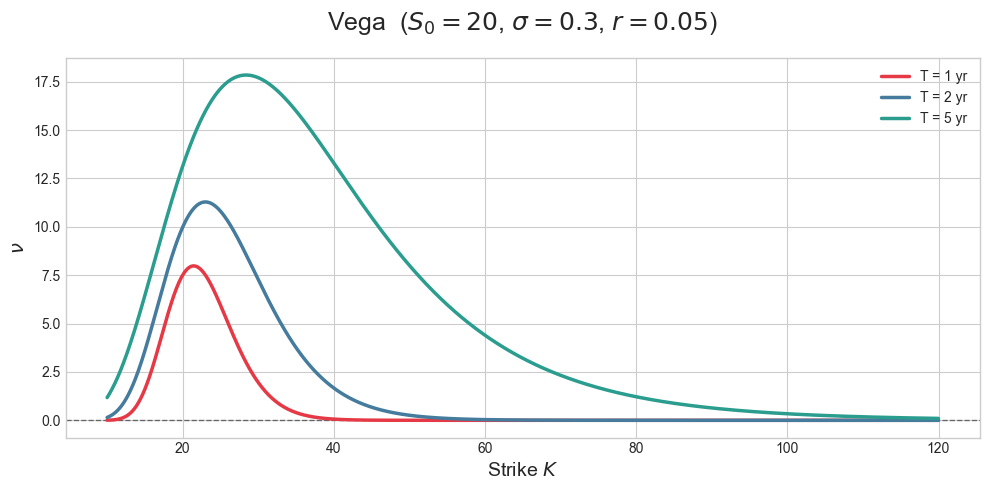

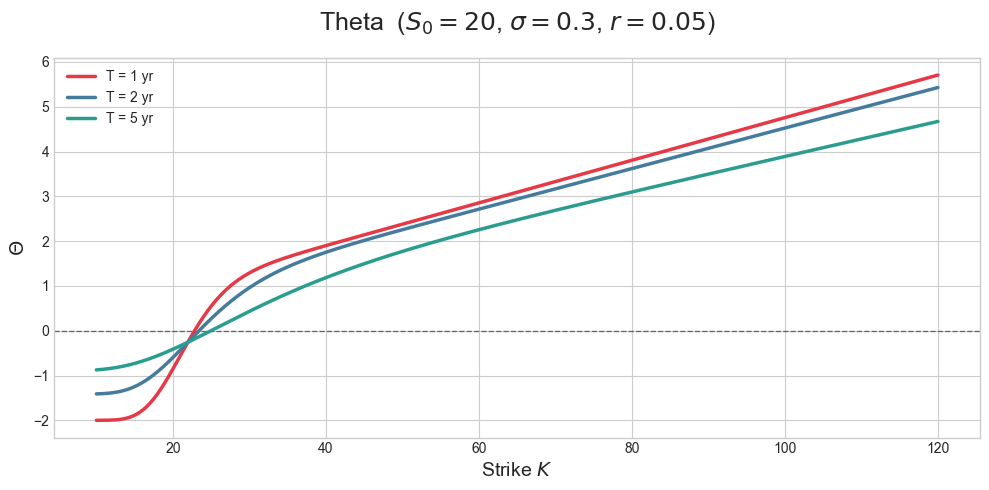

In [20]:
K_vec = np.arange(10, 120, 0.01)
T_vec = [1.0, 2.0, 5.0]
S0 = 20
sigma = 0.3

put_prices, deltas, vegas, thetas, rhos, gammas = zip(
    *[
        black_scholes_eur_put(
            K=K_vec, r=0.05, T=T, S0=20.0, sigma=0.2) for T in T_vec
    ]
)

params = [
    ("European Put Price", list(put_prices), "Price $C$"),
    ("Delta", list(deltas), r"$\Delta$"),
    ("Gamma", list(gammas), r"$\Gamma$"),
    ("Vega", list(vegas), r"$\nu$"),
    ("Theta", list(thetas), r"$\Theta$"),
]

for greek, y_data, y_label in params:
    my_plotter(
        x=K_vec,
        y=y_data,
        names=["T = 1 yr", "T = 2 yr", "T = 5 yr"],
        layout={
             "title": rf"{greek}  ($S_0={S0}$, $\sigma={sigma}$, $r=0.05$)",
            "x_label": "Strike $K$",
            "y_label": y_label,
        },
    )

In [11]:
K_vec = np.arange(10, 30, 0.01)
T_vec = [1.0, 2.0, 5.0]
r = 0.05
S0 = 100
sigma = 0.3
K = 100

put_prices = list(zip(
    *[
        black_scholes_eur_put(
            K=K_vec,
            r=r,
            T=T,
            S0=S0,
            sigma=sigma) for T in T_vec
    ]
))[0]

call_prices = list(zip(
    *[
        black_scholes_eur_call(
            K=K_vec,
            r=r,
            T=T,
            S0=S0,
            sigma=sigma) for T in T_vec
    ]
))[0]

left_side = np.array(call_prices) - np.array(put_prices)
right_side = S0 - K_vec[None, :] * np.exp(-r * np.array(T_vec)[:, None])

residuals = left_side - right_side

if residuals.all() == 0:
    print("Put-Call parity holds.")
else:
    print("Put-Call parity does not hold.")

Put-Call parity holds.
